In [2]:
import numpy as np 
import pandas as pd
from sklearn.decomposition import MiniBatchDictionaryLearning
import os
from sklearn.feature_extraction.image import extract_patches_2d, reconstruct_from_patches_2d

In [ ]:
patch_size = (8,8)
all_patches = []


folder_path = 'C:/Users/Augusto Vieira/Desktop/Nuclear Launch Codes/Python\Machine Learning/Boca3Jun26_200mW_200mW_2932cm_10x_G70_CARS_200x200_700x700_1us'
txt_files = [f for f in os.listdir(folder_path) if f.endswith('.txt')]
print(txt_files)
print(f"Found {len(txt_files)} files. Extracting Patches...")

['20260602_230457.txt', '20260602_230458.txt', '20260602_230500.txt', '20260602_230502.txt', '20260602_230503.txt', '20260602_230505.txt', '20260602_230507.txt', '20260602_230508.txt', '20260602_230510.txt', '20260602_230512.txt', '20260602_230513.txt', '20260602_230515.txt', '20260602_230517.txt', '20260602_230518.txt', '20260602_230520.txt', '20260602_230522.txt', '20260602_230523.txt', '20260602_230525.txt', '20260602_230527.txt', '20260602_230528.txt', '20260602_230530.txt', '20260602_230724.txt', '20260602_230725.txt', '20260602_230727.txt', '20260602_230729.txt', '20260602_230731.txt', '20260602_230732.txt', '20260602_230734.txt', '20260602_230736.txt', '20260602_230738.txt', '20260602_230739.txt', '20260602_230741.txt', '20260602_230743.txt', '20260602_230744.txt', '20260602_230746.txt', '20260602_230748.txt', '20260602_230750.txt', '20260602_230751.txt', '20260602_230753.txt', '20260602_230755.txt', '20260602_230757.txt', '20260602_230758.txt', '20260602_230800.txt', '20260602_

<>:4: SyntaxWarning: "\M" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\M"? A raw string is also an option.
<>:4: SyntaxWarning: "\M" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\M"? A raw string is also an option.
C:\Users\Augusto Vieira\AppData\Local\Temp\ipykernel_16536\2259864551.py:4: SyntaxWarning: "\M" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\M"? A raw string is also an option.
  folder_path = 'C:/Users/Augusto Vieira/Desktop/Nuclear Launch Codes/Python\Machine Learning/Boca3Jun26_200mW_200mW_2932cm_10x_G70_CARS_200x200_700x700_1us'


In [4]:
# for file_name in txt_files: 
#     img_matrix = np.loadtxt(os.path.join(folder_path, file_name))

#     img_matrix = (img_matrix - img_matrix.min()) / (img_matrix.max()-img_matrix.min()) 

#     patches = extract_patches_2d(img_matrix, patch_size)
#     patches = patches.reshape(patches.shape[0], -1)
#     patches -= np.mean(pacthes, axis = 1)[:, np.newaxis]

#     all_patches.append(pacthes)

for file_name in txt_files:
    file_path = os.path.join(folder_path, file_name)
    try:
        df = pd.read_csv(file_path, sep=r'\s+', decimal=',', header=None)
        raw_array = df.to_numpy().flatten()
        
        if raw_array.size != 490000:
            continue
            
        img_matrix = raw_array.reshape(700, 700)
        img_matrix = (img_matrix - img_matrix.min()) / (img_matrix.max() - img_matrix.min())
        
        # CRITICAL FIX: max_patches=5000 limits the data size so your RAM doesn't choke
        patches = extract_patches_2d(img_matrix, patch_size, max_patches=5000, random_state=42)
        patches = patches.reshape(patches.shape[0], -1)
        patches -= np.mean(patches, axis=1)[:, np.newaxis]
        
        all_patches.append(patches)
        print(f"Extracted fast patches from: {file_name}")
        
    except Exception as e:
        print(f"Error skipping {file_name}: {e}")

if all_patches:
    X_train = np.vstack(all_patches)
    print(f"\nOptimized training dataset size: {X_train.shape[0]} rows.")
    
    # CRITICAL FIX: Lowering components to 100 and utilizing more CPU jobs
    print("Training model (Expected time: 30 to 90 seconds)...")
    dict_learner = MiniBatchDictionaryLearning(
        n_components=100, 
        alpha=1.0, 
        batch_size=500, 
        random_state=42,
        n_jobs=-1 # Uses all your computer's CPU cores in parallel
    )
    dict_learner.fit(X_train)
    print("Model training successfully completed in record time!")

Extracted fast patches from: 20260602_230457.txt
Extracted fast patches from: 20260602_230458.txt
Extracted fast patches from: 20260602_230500.txt
Extracted fast patches from: 20260602_230502.txt
Extracted fast patches from: 20260602_230503.txt
Extracted fast patches from: 20260602_230505.txt
Extracted fast patches from: 20260602_230507.txt
Extracted fast patches from: 20260602_230508.txt
Extracted fast patches from: 20260602_230510.txt
Extracted fast patches from: 20260602_230512.txt
Extracted fast patches from: 20260602_230513.txt
Extracted fast patches from: 20260602_230515.txt
Extracted fast patches from: 20260602_230517.txt
Extracted fast patches from: 20260602_230518.txt
Extracted fast patches from: 20260602_230520.txt
Extracted fast patches from: 20260602_230522.txt
Extracted fast patches from: 20260602_230523.txt
Extracted fast patches from: 20260602_230525.txt
Extracted fast patches from: 20260602_230527.txt
Extracted fast patches from: 20260602_230528.txt
Extracted fast patch

Extracting target patches for reconstruction...
Running ML code to filter background noise...
Generating plots...


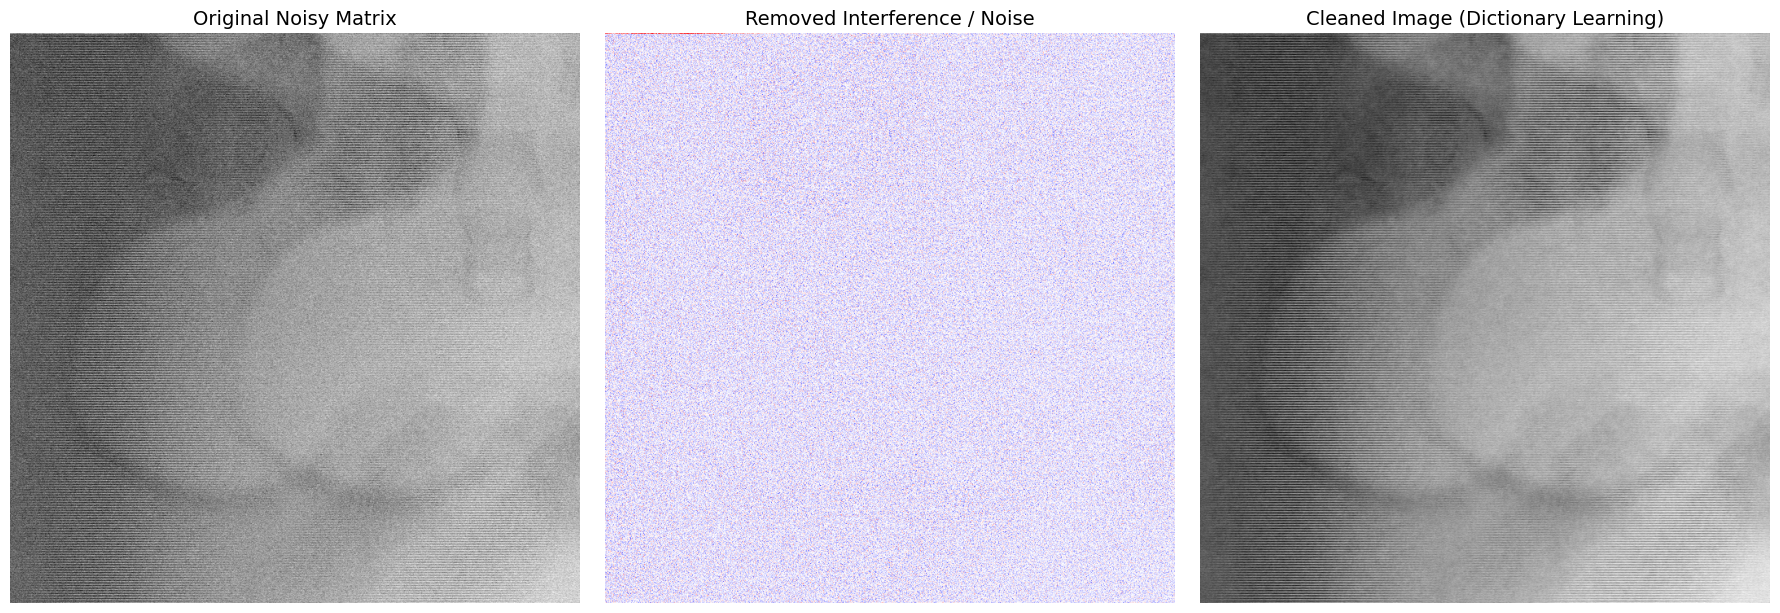

In [5]:
import matplotlib.pyplot as plt
from sklearn.feature_extraction.image import extract_patches_2d, reconstruct_from_patches_2d

# 1. Pick a noisy file to clean (we will use the first file for this example)
sample_file = os.path.join(folder_path, txt_files[0])
df_sample = pd.read_csv(sample_file, sep=r'\s+', decimal=',', header=None)
noisy_img = df_sample.to_numpy().flatten().reshape(700, 700)

# Normalize to 0-1 range
noisy_img = (noisy_img - noisy_img.min()) / (noisy_img.max() - noisy_img.min())

# 2. Extract ALL overlapping patches from this specific image to rebuild it completely
print("Extracting target patches for reconstruction...")
patches = extract_patches_2d(noisy_img, patch_size)
patches_flattened = patches.reshape(patches.shape[0], -1)

# Intercept and remove the local mean of each patch (intercept tracking)
intercepts = np.mean(patches_flattened, axis=1)
patches_centered = patches_flattened - intercepts[:, np.newaxis]

# 3. ML Denoising step: Transform and Reconstruct
print("Running ML code to filter background noise...")
# The model uses Lasso regression to find the cleanest representation of your patches
reconstructed_patches = dict_learner.transform(patches_centered) 
reconstructed_patches = np.dot(reconstructed_patches, dict_learner.components_)

# Add back the patch means
reconstructed_patches += intercepts[:, np.newaxis]
reconstructed_patches = reconstructed_patches.reshape(patches.shape)

# Stitch the patches back into a perfect 700x700 matrix
clean_img = reconstruct_from_patches_2d(reconstructed_patches, (700, 700))

# 4. Isolate the noise/interference pattern
noise_isolated = noisy_img - clean_img

# 5. Plot the Final Results for your Presentation!
print("Generating plots...")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel 1: Original Noisy CARS Matrix
axes[0].imshow(noisy_img, cmap='gray')
axes[0].set_title('Original Noisy Matrix', fontsize=14)
axes[0].axis('off')

# Panel 2: Isolated Interference / Non-resonant Background
axes[1].imshow(noise_isolated, cmap='bwr') # Blue-White-Red spectrum highlights noise variance
axes[1].set_title('Removed Interference / Noise', fontsize=14)
axes[1].axis('off')

# Panel 3: Cleaned ML Image
axes[2].imshow(clean_img, cmap='gray')
axes[2].set_title('Cleaned Image (Dictionary Learning)', fontsize=14)
axes[2].axis('off')

plt.tight_layout()
plt.savefig('CARS_ML_Denoising_Results.png', dpi=300) # Saves a high-res image for your slides
plt.show()

In [6]:
matrix_sum = np.zeros((700, 700))
valid_file_count = 0

print(f"Averaging {len(txt_files)} files...")

# 2. Sum up all the matrices
for file_name in txt_files:
    file_path = os.path.join(folder_path, file_name)
    try:
        # Load exactly like before
        df = pd.read_csv(file_path, sep=r'\s+', decimal=',', header=None)
        img_matrix = df.to_numpy().flatten()
        
        if img_matrix.size == 490000:
            matrix_sum += img_matrix.reshape(700, 700)
            valid_file_count += 1
    except Exception as e:
        print(f"Skipping {file_name} due to error: {e}")

# 3. Calculate the true average matrix
if valid_file_count > 0:
    average_matrix = matrix_sum / valid_file_count
    print(f"Successfully averaged {valid_file_count} frames.")
    
    # 4. Save the average matrix back to a new text file
    # We use np.savetxt, formatting numbers as floats (%f)
    output_filename = 'CARS_700x700_Average_Matrix.txt'
    
    # To keep consistency with your original files, we can save it with commas as decimals
    # By default, Python saves with dots, so we convert the text output:
    with open(output_filename, 'w') as f:
        for row in average_matrix:
            # Convert row numbers to strings, replace dots with commas, join with spaces
            row_str = ' '.join([f"{val:.6f}".replace('.', ',') for val in row])
            f.write(row_str + '\n')
            
    print(f"Saved new average matrix file as: '{output_filename}'")
else:
    print("No valid 700x700 matrices found to average.")

Averaging 56 files...
Successfully averaged 56 frames.
Saved new average matrix file as: 'CARS_700x700_Average_Matrix.txt'


Extracting target patches for reconstruction...
Running ML code to filter background noise...
Generating plots...


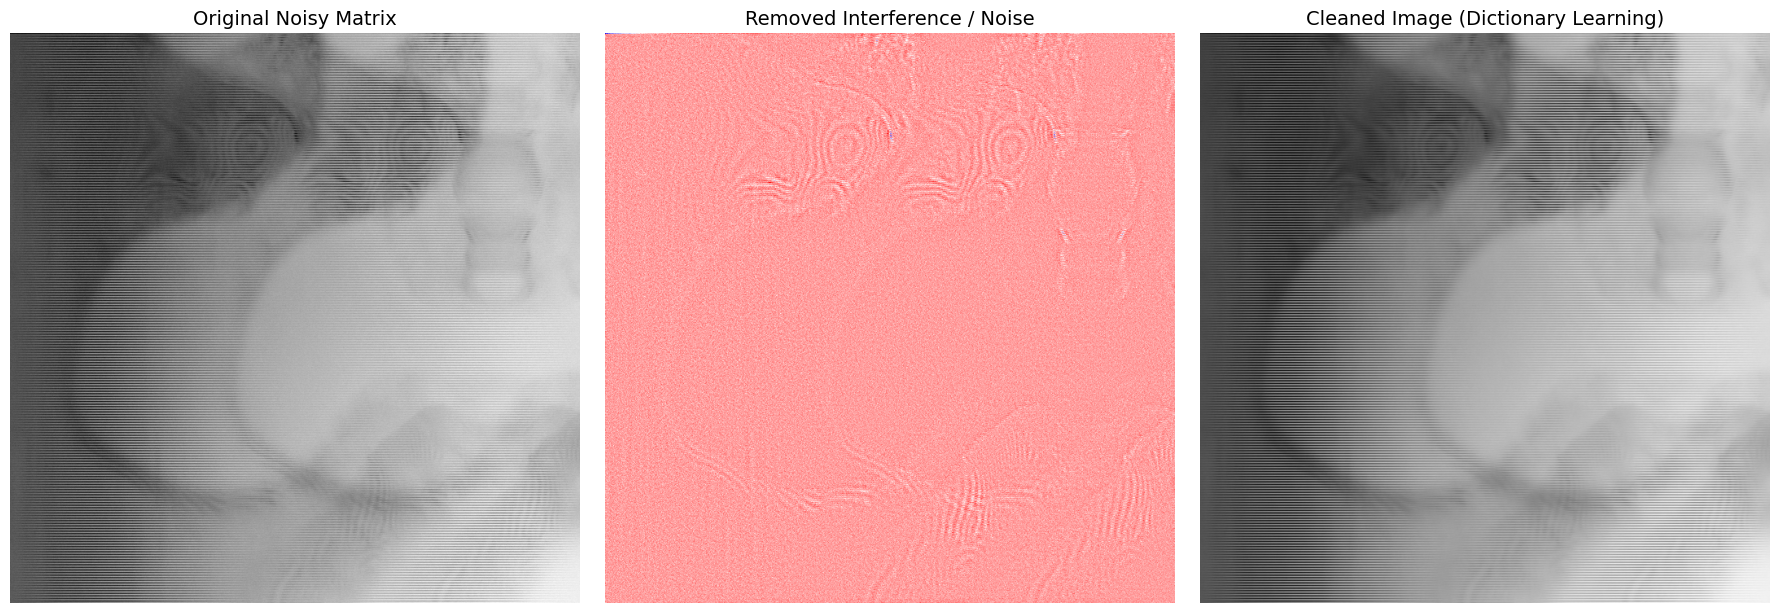

In [7]:
import matplotlib.pyplot as plt
from sklearn.feature_extraction.image import extract_patches_2d, reconstruct_from_patches_2d

# 1. Pick a noisy file to clean (we will use the first file for this example)
sample_file = 'CARS_700x700_Average_Matrix.txt'
df_sample = pd.read_csv(sample_file, sep=r'\s+', decimal=',', header=None)
noisy_img = df_sample.to_numpy().flatten().reshape(700, 700)

# Normalize to 0-1 range
noisy_img = (noisy_img - noisy_img.min()) / (noisy_img.max() - noisy_img.min())

# 2. Extract ALL overlapping patches from this specific image to rebuild it completely
print("Extracting target patches for reconstruction...")
patches = extract_patches_2d(noisy_img, patch_size)
patches_flattened = patches.reshape(patches.shape[0], -1)

# Intercept and remove the local mean of each patch (intercept tracking)
intercepts = np.mean(patches_flattened, axis=1)
patches_centered = patches_flattened - intercepts[:, np.newaxis]

# 3. ML Denoising step: Transform and Reconstruct
print("Running ML code to filter background noise...")
# The model uses Lasso regression to find the cleanest representation of your patches
reconstructed_patches = dict_learner.transform(patches_centered) 
reconstructed_patches = np.dot(reconstructed_patches, dict_learner.components_)

# Add back the patch means
reconstructed_patches += intercepts[:, np.newaxis]
reconstructed_patches = reconstructed_patches.reshape(patches.shape)

# Stitch the patches back into a perfect 700x700 matrix
clean_img = reconstruct_from_patches_2d(reconstructed_patches, (700, 700))

# 4. Isolate the noise/interference pattern
noise_isolated = noisy_img - clean_img

# 5. Plot the Final Results for your Presentation!
print("Generating plots...")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel 1: Original Noisy CARS Matrix
axes[0].imshow(noisy_img, cmap='gray')
axes[0].set_title('Original Noisy Matrix', fontsize=14)
axes[0].axis('off')

# Panel 2: Isolated Interference / Non-resonant Background
axes[1].imshow(noise_isolated, cmap='bwr') # Blue-White-Red spectrum highlights noise variance
axes[1].set_title('Removed Interference / Noise', fontsize=14)
axes[1].axis('off')

# Panel 3: Cleaned ML Image
axes[2].imshow(clean_img, cmap='gray')
axes[2].set_title('Cleaned Image (Dictionary Learning)', fontsize=14)
axes[2].axis('off')

plt.tight_layout()
plt.savefig('CARS_ML_Denoising_Results.png', dpi=300) # Saves a high-res image for your slides
plt.show()